In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# Standard and ML Libraries
import os
import cv2
import numpy as np
import pandas as pd
import random
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import defaultdict
from PIL import Image
import time  # Added from BACH code
import csv   # Added from BACH code

# PyTorch Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import timm

# Scikit-learn Libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("All libraries installed and imported successfully.")

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda
All libraries installed and imported successfully.


Found 400 images belonging to 4 classes.
Class Mapping: {0: 'Normal', 1: 'Benign', 2: 'InSitu', 3: 'Invasive'}

Original Class Distribution:


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


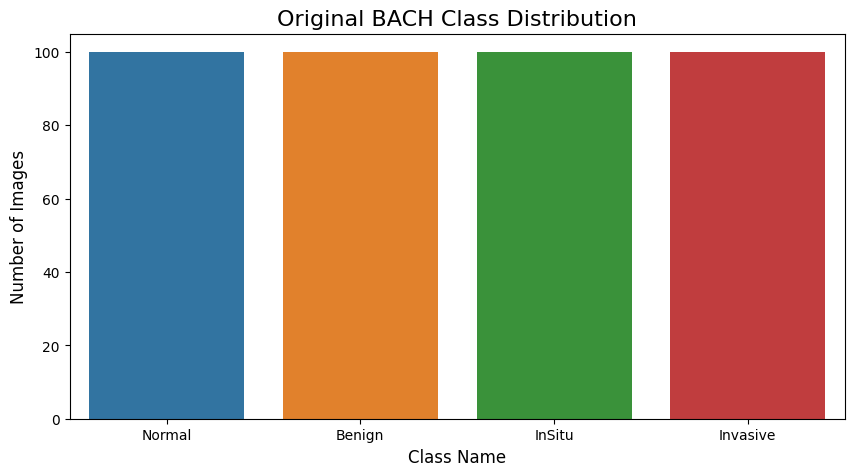

In [2]:
def plot_class_distributions(labels, class_names, title):
    """Plots the distribution of classes."""
    class_counts = defaultdict(int)
    for label in labels:
        class_counts[label] += 1
    
    sorted_counts = [class_counts[i] for i in range(len(class_names))]
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=class_names, y=sorted_counts)
    plt.title(title, fontsize=16)
    plt.xlabel("Class Name", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.xticks(rotation=0)
    plt.show()

def read_bach_data(base_path):
    """
    Reads the BACH dataset and organizes it.
    Returns: image_paths, labels, and label_map
    """
    all_images, all_labels = [], []
    
    # Define the class names and their corresponding integer labels
    # Using the same mapping as your BACH code: 0:Normal, 1:Benign, 2:InSitu, 3:Invasive
    class_names_list = ["Normal", "Benign", "InSitu", "Invasive"]
    label_map = {i: name for i, name in enumerate(class_names_list)}
    
    for class_name in class_names_list:
        class_path = os.path.join(base_path, class_name)
        current_class_label = list(label_map.values()).index(class_name)
        
        if not os.path.isdir(class_path):
            print(f"Warning: Directory not found {class_path}")
            continue
            
        for img_name in os.listdir(class_path):
            if img_name.endswith(".tif"):
                full_path = os.path.join(class_path, img_name)
                all_images.append(full_path)
                all_labels.append(current_class_label)
                
    return all_images, all_labels, label_map

# Use BACH dataset path
base_path = "/kaggle/input/bach-breast-cancer-histology-images/ICIAR2018_BACH_Challenge/ICIAR2018_BACH_Challenge/Photos"
all_images, all_labels, label_map = read_bach_data(base_path)

NUM_CLASSES = len(label_map)
CLASS_NAMES = [label_map[i] for i in range(NUM_CLASSES)]

print(f"Found {len(all_images)} images belonging to {NUM_CLASSES} classes.")
print("Class Mapping:", label_map)

print("\nOriginal Class Distribution:")
plot_class_distributions(all_labels, CLASS_NAMES, "Original BACH Class Distribution")

Original distribution: {0: 100, 1: 100, 2: 100, 3: 100}
Targeting 2000 samples per class.
Oversampling class 0 from 100 to 2000
Oversampling class 1 from 100 to 2000
Oversampling class 2 from 100 to 2000
Oversampling class 3 from 100 to 2000

Total images after balancing: 8000
Balanced Class Distribution:


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


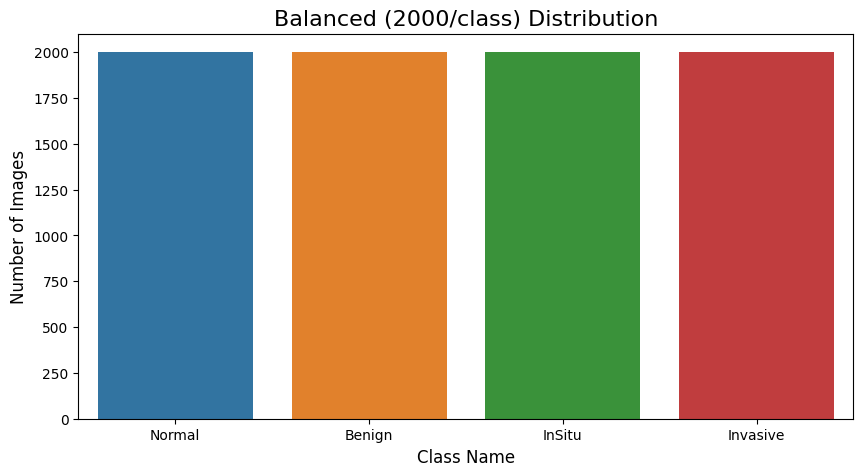

In [3]:
# Cell 3: Data Balancing by Oversampling
def balance_dataset(image_paths, labels, target_count=2000):
    """Balances the dataset so each class has the target number of samples."""
    class_distribution = {k: v for k, v in zip(*np.unique(labels, return_counts=True))}
    print(f"Original distribution: {class_distribution}")
    print(f"Targeting {target_count} samples per class.")
    
    balanced_image_paths, balanced_labels = [], []
    
    for class_id, count in class_distribution.items():
        class_indices = [i for i, label in enumerate(labels) if label == class_id]
        class_images = [image_paths[i] for i in class_indices]
        
        if count < target_count: # Oversample
            print(f"Oversampling class {class_id} from {count} to {target_count}")
            chosen_images = random.choices(class_images, k=target_count)
        elif count > target_count: # Undersample
            print(f"Undersampling class {class_id} from {count} to {target_count}")
            chosen_images = random.sample(class_images, k=target_count)
        else: # Count is already at target
            print(f"Class {class_id} is already at {target_count} samples.")
            chosen_images = class_images
            
        balanced_image_paths.extend(chosen_images)
        balanced_labels.extend([class_id] * target_count)
        
    return balanced_image_paths, balanced_labels

# The BACH dataset is perfectly balanced (100 images each), so this will oversample all classes.
balanced_image_paths, balanced_labels = balance_dataset(all_images, all_labels, target_count=2000)

print(f"\nTotal images after balancing: {len(balanced_image_paths)}")
print("Balanced Class Distribution:")
plot_class_distributions(balanced_labels, CLASS_NAMES, "Balanced (2000/class) Distribution")

Visualizing the effect of CLAHE preprocessing:


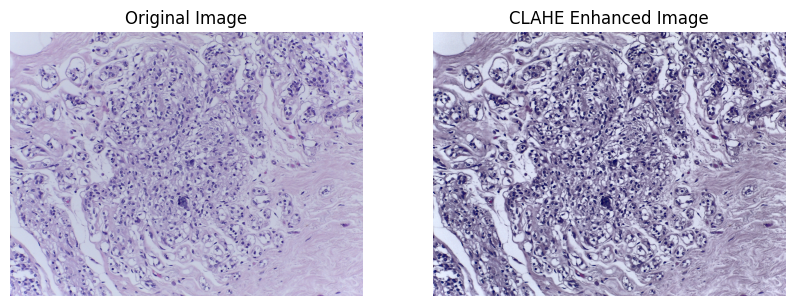

In [4]:
def apply_clahe_to_color_image(image):
    """Applies CLAHE contrast enhancement to a color image."""
    # Convert BGR (from cv2.imread) to LAB
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    # Apply CLAHE to the L-channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    
    # Merge the CLAHE-enhanced L-channel back with a and b channels
    lab = cv2.merge((cl, a, b))
    
    # Convert LAB back to RGB for PIL/transforms
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB) 

class BACHDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None, apply_clahe=False):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.apply_clahe = apply_clahe

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Load image with OpenCV (reads as BGR)
        image = cv2.imread(image_path)
        
        # Apply CLAHE if specified
        if self.apply_clahe:
            image = apply_clahe_to_color_image(image)
        else:
            # Just convert BGR to RGB
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
        # Convert to PIL Image to apply torchvision transforms
        image = Image.fromarray(image)
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

# Visualize an original vs. CLAHE-enhanced image
def visualize_clahe(image_path):
    original_img = cv2.imread(image_path) # BGR
    clahe_img = apply_clahe_to_color_image(original_img) # RGB
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(clahe_img)
    plt.title("CLAHE Enhanced Image")
    plt.axis('off')
    plt.show()

print("Visualizing the effect of CLAHE preprocessing:")
visualize_clahe(random.choice(balanced_image_paths))

In [5]:
# Cell 5: Data Splitting and DataLoader Creation

# Split data into training (70%), validation (15%), and test (15%)
# Note: We split the *balanced* list of 8000 paths
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    balanced_image_paths, balanced_labels, test_size=0.3, random_state=SEED, stratify=balanced_labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print(f"Total balanced samples: {len(balanced_image_paths)}")
print(f"Training samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Test samples: {len(test_paths)}")

# Define transforms
IMG_SIZE = 224
BATCH_SIZE = 32 

# ADDED shift (translate) and shear to the training transforms
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    # This single transform handles rotation, shift, and shear
    transforms.RandomAffine(
        degrees=20,         # Rotation
        translate=(0.1, 0.1), # Shift (10% in x and y)
        shear=10            # Shear
    ),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Create Dataset instances
# We apply CLAHE to all splits as it's a preprocessing step
train_ds = BACHDataset(train_paths, train_labels, transform=train_tfms, apply_clahe=True)
val_ds = BACHDataset(val_paths, val_labels, transform=val_test_tfms, apply_clahe=True)
test_ds = BACHDataset(test_paths, test_labels, transform=val_test_tfms, apply_clahe=True)

# Create DataLoader instances
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nDataLoaders created successfully with heavy augmentation on the train set.")

Total balanced samples: 8000
Training samples: 5600
Validation samples: 1200
Test samples: 1200

DataLoaders created successfully with heavy augmentation on the train set.


In [6]:
# --- CNN Ensemble (SqueezeNet + ShuffleNet) ---
class CNNEnsemble(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        squeezenet = models.squeezenet1_1(pretrained=pretrained)
        self.squeezenet_features = squeezenet.features
        self.squeeze_out_dim = 512
        
        shufflenet = models.shufflenet_v2_x1_0(pretrained=pretrained)
        self.shufflenet_features = nn.Sequential(
            shufflenet.conv1,
            shufflenet.maxpool,
            shufflenet.stage2,
            shufflenet.stage3,
            shufflenet.stage4,
            shufflenet.conv5
        )
        self.shuffle_out_dim = 1024
        
        # Fusion layer to combine features
        self.fusion_conv = nn.Conv2d(
            self.squeeze_out_dim + self.shuffle_out_dim, 512, kernel_size=1
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        
    def forward(self, x):
        s = self.squeezenet_features(x)
        sh = self.shufflenet_features(x)
        
        # Interpolate shufflenet features to match squeezenet spatial dimensions
        if s.size()[2:] != sh.size()[2:]:
            sh = F.interpolate(sh, size=s.size()[2:], mode="bilinear", align_corners=False)
            
        fused = torch.cat([s, sh], dim=1)
        fused = self.fusion_conv(fused)
        
        pooled = self.pool(fused)
        out = torch.flatten(pooled, 1)
        return fused, out # Return both feature map and pooled vector

# --- Swin Transformer Backbone (Corrected) ---
class SwinTransformerBackbone(nn.Module):
    def __init__(self, model_name="swin_tiny_patch4_window7_224", pretrained=True):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=pretrained, features_only=True)
        # Get the number of output channels from the last feature map
        self.out_channels = self.model.feature_info[-1]['num_chs']
        
    def forward(self, x):
        # timm models return a list of feature maps, [-1] is the last one
        # feats has a channels-last shape: [B, H, W, C]
        feats_channels_last = self.model(x)[-1] 
        
        # FIX: Permute to channels-first [B, C, H, W] for consistent pooling/conv
        feats_channels_first = feats_channels_last.permute(0, 3, 1, 2)
        
        # Pool over the spatial dimensions (H, W)
        pooled = feats_channels_first.mean(dim=[2, 3])
        
        # Return the channels-first feature map and the pooled vector
        return feats_channels_first, pooled

# --- FiLM Layer ---
class FiLMLayer(nn.Module):
    def __init__(self, cnn_channels, swin_embed_dim):
        super().__init__()
        # Linear layers to generate gamma (scaling) and beta (shifting) parameters
        self.gamma_fc = nn.Linear(swin_embed_dim, cnn_channels)
        self.beta_fc = nn.Linear(swin_embed_dim, cnn_channels)
        
    def forward(self, cnn_features, swin_vector):
        # swin_vector is [B, D]
        # Generate gamma and beta, shape [B, cnn_channels]
        gamma = self.gamma_fc(swin_vector)
        beta = self.beta_fc(swin_vector)
        
        # Reshape to [B, cnn_channels, 1, 1] for broadcasting
        gamma = gamma.unsqueeze(-1).unsqueeze(-1)
        beta = beta.unsqueeze(-1).unsqueeze(-1)
        
        # Apply FiLM: y = gamma * x + beta
        return cnn_features * gamma + beta

# --- Dual Branch FiLM Network ---
class DualBranchFiLMNetwork(nn.Module):
    def __init__(self, num_classes, pretrained=True, swin_model="swin_tiny_patch4_window7_224"):
        super().__init__()
        self.cnn_branch = CNNEnsemble(num_classes=num_classes, pretrained=pretrained)
        self.vit_branch = SwinTransformerBackbone(model_name=swin_model, pretrained=pretrained)
        
        # FiLM layer to modulate CNN features using Swin features
        self.film = FiLMLayer(cnn_channels=512, swin_embed_dim=self.vit_branch.out_channels)
        
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        # Classifier takes concatenated features from both branches
        self.classifier = nn.Linear(512 + self.vit_branch.out_channels, num_classes)
        
    def forward(self, x):
        # Get features from both branches
        cnn_feats, _ = self.cnn_branch(x) # cnn_feats is [B, 512, H, W]
        _, swin_vec = self.vit_branch(x)   # swin_vec is [B, D_swin]
        
        # Modulate the CNN feature map using the Swin vector
        modulated_cnn = self.film(cnn_feats, swin_vec)
        
        # Pool the modulated features
        pooled_cnn = self.pool(modulated_cnn)
        pooled_cnn = torch.flatten(pooled_cnn, 1) # [B, 512]
        
        # Concatenate with the original Swin vector
        fused = torch.cat([pooled_cnn, swin_vec], dim=1)
        
        # Classify
        out = self.classifier(fused)
        return out

print("DualBranchFiLMNetwork model definition is ready.")

DualBranchFiLMNetwork model definition is ready.


In [7]:
def train_model(model, train_loader, val_loader, model_name="dualbranch_film", epochs=25, lr=1e-4, patience=7):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    
    # Cosine Annealing scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    # Automatic Mixed Precision (AMP) scaler
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
    
    best_acc = 0.0
    best_ckpt_path = f"/kaggle/working/{model_name}_best.pth"
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    no_improve_epochs = 0
    
    print(f"Starting training for {epochs} epochs...")
    
    for epoch in range(1, epochs + 1):
        # --- Training Phase ---
        model.train()
        running_loss, running_corrects, total = 0.0, 0, 0
        pbar_train = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [T]", leave=False)
        
        for inputs, labels in pbar_train:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            # Use AMP
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
            # Scale loss and backprop
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data).item()
            total += labels.size(0)
            
            pbar_train.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{running_corrects/total:.4f}")
            
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects / len(train_loader.dataset)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        
        # --- Validation Phase ---
        model.eval()
        val_loss, val_corrects, val_total = 0.0, 0, 0
        pbar_val = tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [V]", leave=False)
        
        with torch.no_grad():
            for inputs, labels in pbar_val:
                inputs, labels = inputs.to(device), labels.to(device)
                
                # AMP for validation (inference)
                with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data).item()
                val_total += labels.size(0)
                pbar_val.set_postfix(loss=f"{val_loss/val_total:.4f}", acc=f"{val_corrects/val_total:.4f}")

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_corrects / len(val_loader.dataset)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        # Step the scheduler
        scheduler.step()
        
        print(f"Epoch {epoch:02d}: Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        
        # Checkpoint and Early Stopping
        if val_acc > best_acc:
            best_acc = val_acc
            no_improve_epochs = 0
            torch.save(model.state_dict(), best_ckpt_path)
            print(f" -> New best model saved with accuracy: {best_acc:.4f}")
        else:
            no_improve_epochs += 1
            
        if no_improve_epochs >= patience:
            print(f"Early stopping triggered after {patience} epochs with no improvement.")
            break
            
    print(f"\nTraining finished. Best val Acc: {best_acc:.4f}")
    
    # Load the best model weights
    model.load_state_dict(torch.load(best_ckpt_path))
    return model, history, best_ckpt_path

# --- Instantiate model & train ---
PRETRAINED = True 
model = DualBranchFiLMNetwork(num_classes=NUM_CLASSES, pretrained=PRETRAINED)
model = model.to(device)

print(f"Model instantiated for {NUM_CLASSES} classes.")
print(f"Trainable parameters (approx): {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.2f}M")

# Train
model, history, ckpt_path = train_model(
    model,
    train_loader,
    val_loader,
    model_name="DualBranchFiLM_BACH",
    epochs=20,    # Increased epochs for this dataset
    lr=5e-5,
    patience=10
)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth
100%|██████████| 4.73M/4.73M [00:00<00:00, 143MB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Model instantiated for 4 classes.
Trainable parameters (approx): 31.07M
Starting training for 20 epochs...


/tmp/ipykernel_48/4135465521.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


Epoch 1/20 [T]:   0%|          | 0/175 [00:00<?, ?it/s]

...

Epoch 13/20 [V]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 13: Train Loss: 0.0012 Acc: 0.9996 | Val Loss: 0.0000 Acc: 1.0000


Epoch 14/20 [T]:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 14/20 [V]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 14: Train Loss: 0.0082 Acc: 0.9980 | Val Loss: 0.0003 Acc: 1.0000
Early stopping triggered after 10 epochs with no improvement.

Training finished. Best val Acc: 1.0000


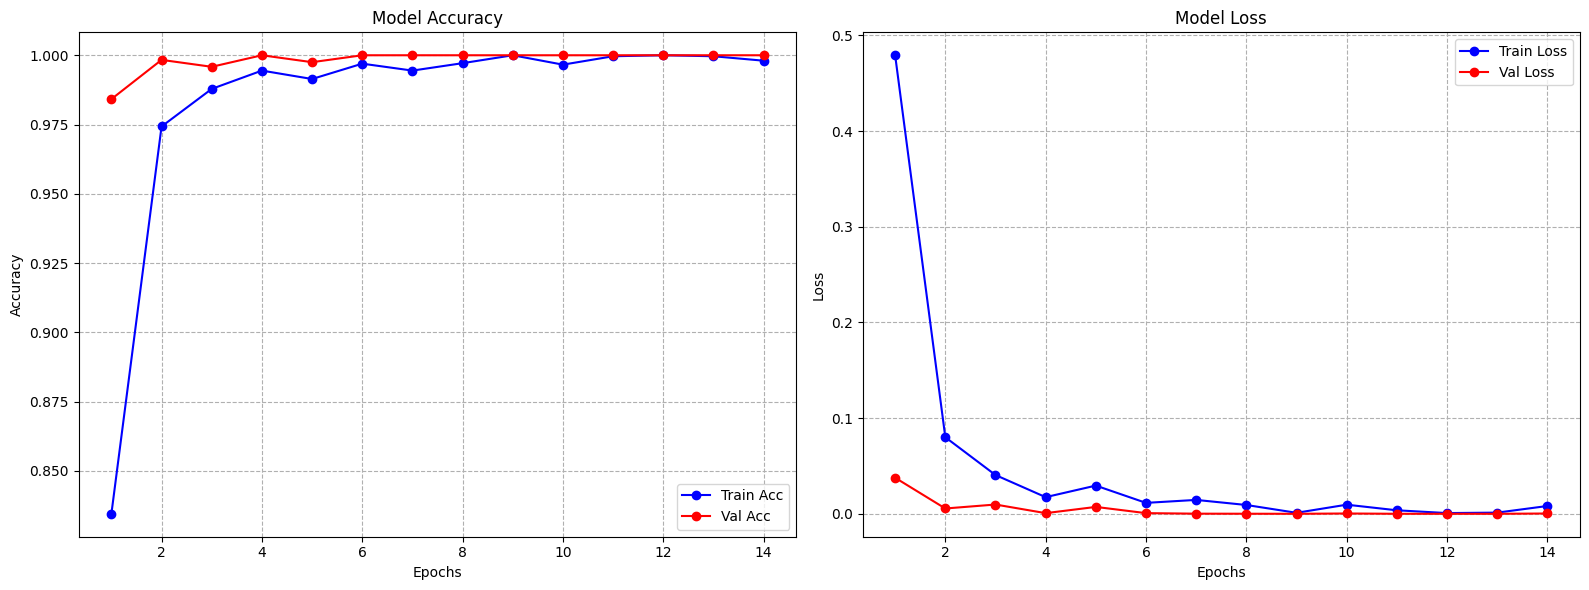

Final Evaluation on Test Set:   0%|          | 0/38 [00:00<?, ?it/s]


           Classification Report
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000       300
      Benign     1.0000    1.0000    1.0000       300
      InSitu     1.0000    1.0000    1.0000       300
    Invasive     1.0000    1.0000    1.0000       300

    accuracy                         1.0000      1200
   macro avg     1.0000    1.0000    1.0000      1200
weighted avg     1.0000    1.0000    1.0000      1200



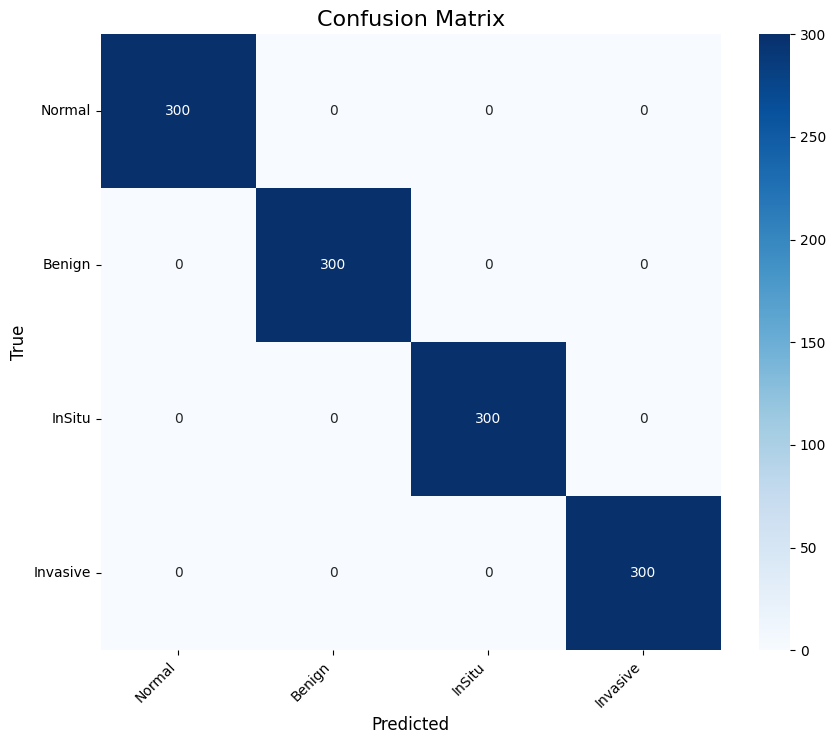

In [9]:
# Cell 8: Plot training history and evaluation
# -------------------------
def plot_training_history(history):
    train_acc = history['train_acc']
    val_acc = history['val_acc']
    train_loss = history['train_loss']
    val_loss = history['val_loss']
    epochs = range(1, len(train_acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.plot(epochs, train_acc, 'b-o', label='Train Acc')
    ax1.plot(epochs, val_acc, 'r-o', label='Val Acc')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, linestyle='--')

    ax2.plot(epochs, train_loss, 'b-o', label='Train Loss')
    ax2.plot(epochs, val_loss, 'r-o', label='Val Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, linestyle='--')

    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Final evaluation on test set
def evaluate_model(model, loader, ckpt_path, class_names):
    model.load_state_dict(torch.load(ckpt_path))
    model.to(device)
    model.eval()

    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Final Evaluation on Test Set"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    print("\n" + "="*50)
    print("           Classification Report")
    print("="*50)
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("True", fontsize=12)
    plt.title("Confusion Matrix", fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

evaluate_model(model, test_loader, ckpt_path, CLASS_NAMES)


--- Generating GradCAM visualizations for target layer: FiLMLayer ---


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


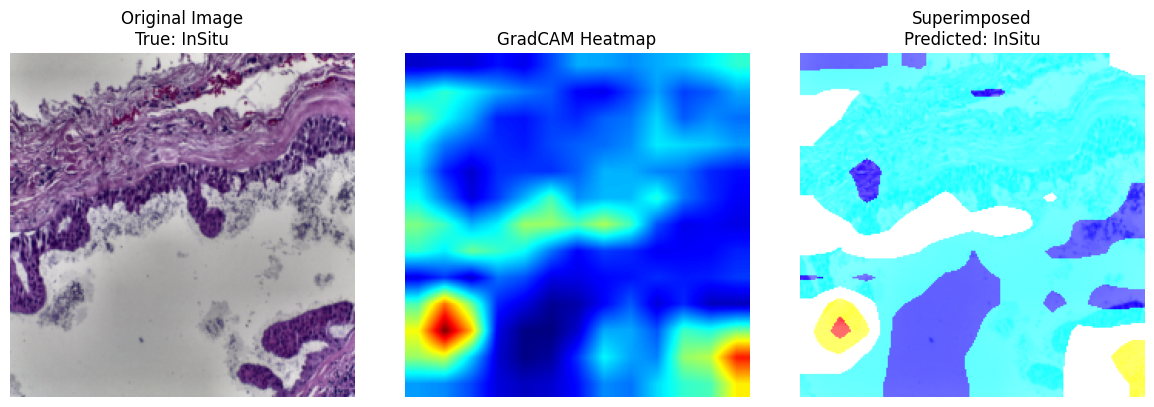

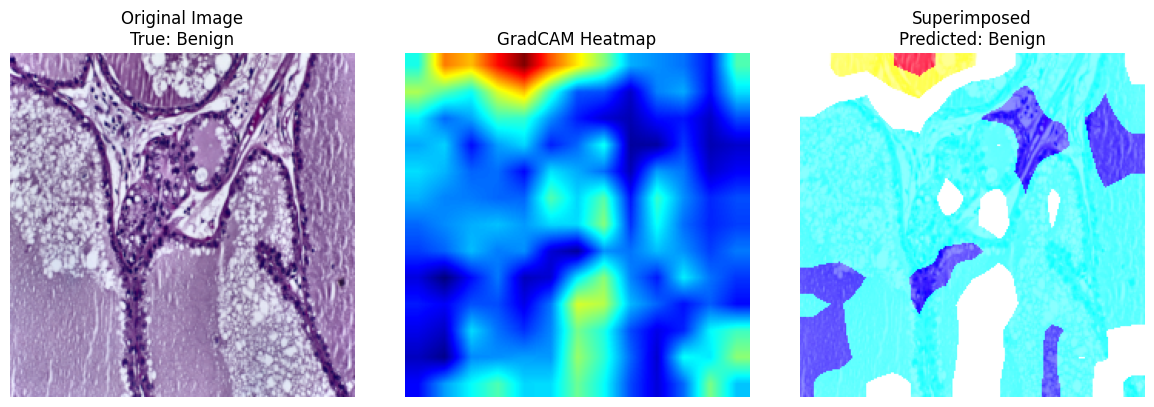

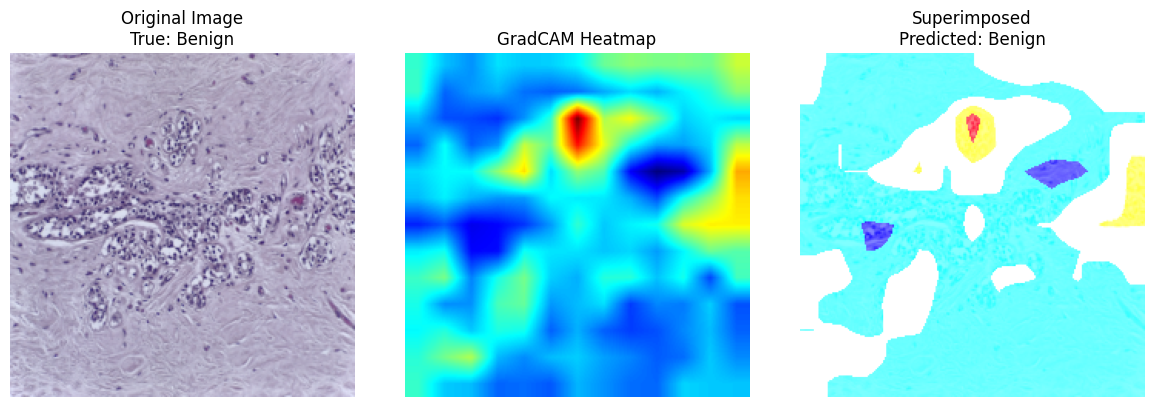

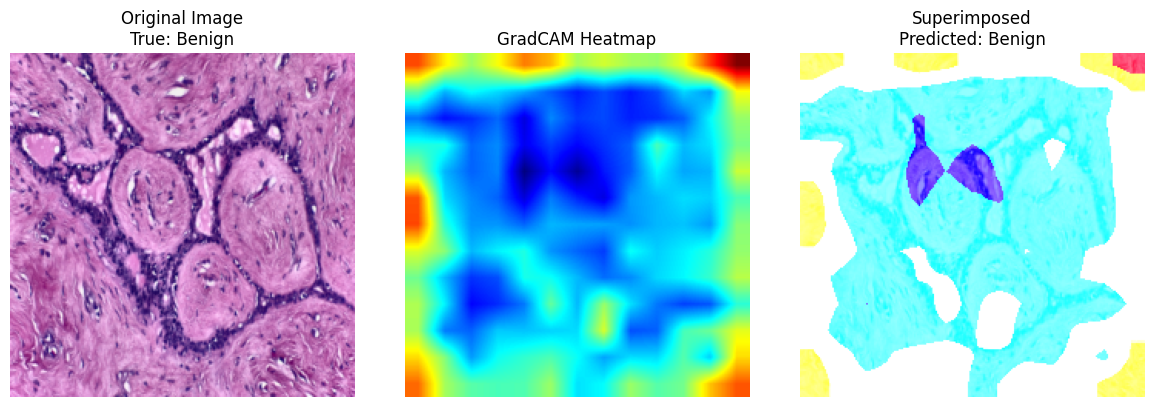

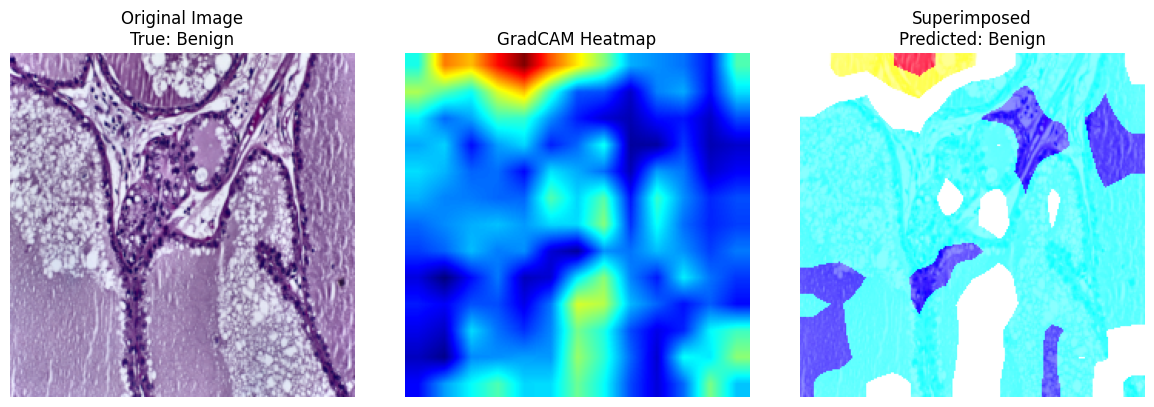

In [10]:
class GradCAM:
    """
    Implements GradCAM (Gradient-weighted Class Activation Mapping) for a given model.
    It hooks into a target layer to get activations and gradients.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        # Store the activations from the forward pass
        self.activations = output
    
    def backward_hook(self, module, grad_in, grad_out):
        # Store the gradients from the backward pass
        self.gradients = grad_out[0]
        
    def __call__(self, input_tensor, class_idx=None):
        # 1. Forward pass
        input_tensor = input_tensor.to(device)
        self.model.eval()
        output = self.model(input_tensor)
        
        if class_idx is None:
            # If no class index is specified, use the predicted class
            class_idx = torch.argmax(output, dim=1).item()
            
        # 2. Backward pass
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot, retain_graph=True)
        
        # 3. Get gradients and activations
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        
        # 4. Global Average Pooling of gradients (weights)
        weights = np.mean(gradients, axis=(1, 2)) # Shape: (n_channels,)
        
        # 5. Create CAM
        cam = np.zeros(activations.shape[1:], dtype=np.float32) # Shape: (H, W)
        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]
            
        # 6. Post-process CAM (ReLU and Normalize)
        cam = np.maximum(cam, 0) # ReLU
        cam = cv2.resize(cam, (input_tensor.shape[2], input_tensor.shape[3]))
        if np.max(cam) > 0:
            cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam))
        return cam, class_idx

def unnormalize(tensor_img):
    """Un-normalizes a tensor image for plotting."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor_img.permute(1, 2, 0).cpu().numpy() # C, H, W -> H, W, C
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

def plot_gradcam(model, target_layer, loader, class_names, num_images=5):
    """Selects, computes, and plots GradCAM for a few images."""
    print(f"\n--- Generating GradCAM visualizations for target layer: {target_layer.__class__.__name__} ---")
    grad_cam = GradCAM(model, target_layer)
    
    # Get a batch of images
    images, labels = next(iter(loader))
    images = images.to(device)
    
    for i in range(min(num_images, len(images))):
        img_tensor = images[i].unsqueeze(0) # [1, C, H, W]
        true_label = labels[i].item()
        
        # Generate CAM
        cam, pred_idx = grad_cam(img_tensor)
        
        # Prepare image for plotting
        original_img = unnormalize(images[i])
        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        
        # Superimpose CAM on original image
        superimposed_img = heatmap * 0.4 + original_img * 0.6
        superimposed_img = np.clip(superimposed_img, 0, 1)
        
        # Plot
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(original_img)
        plt.title(f"Original Image\nTrue: {class_names[true_label]}")
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.imshow(heatmap)
        plt.title("GradCAM Heatmap")
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        plt.imshow(superimposed_img)
        plt.title(f"Superimposed\nPredicted: {class_names[pred_idx]}")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()

# --- Run GradCAM ---
# We will target the FiLM layer, which modulates the CNN features
# This layer's output (`modulated_cnn`) is a great indicator of what the
# combined model is focusing on.
target_layer = model.film 
plot_gradcam(model, target_layer, test_loader, CLASS_NAMES, num_images=5)